In [15]:
from IPython.display import Image, display
!pip3 install vsketch vpype vpype-gcode websocket-client matplotlib numpy

  Cloning https://github.com/abey79/vpype/ (to revision master) to /private/var/folders/b5/0ytjq561357277rwx5t5p9r40000gn/T/pip-install-hpgvwx32/vpype_038b60e90acb4dc59ef4d16d383fd9f8
  Running command git clone --filter=blob:none --quiet https://github.com/abey79/vpype/ /private/var/folders/b5/0ytjq561357277rwx5t5p9r40000gn/T/pip-install-hpgvwx32/vpype_038b60e90acb4dc59ef4d16d383fd9f8
  Resolved https://github.com/abey79/vpype/ to commit 3dbc352d3e4f37c20ff3d28e7f56235da2c139ed
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


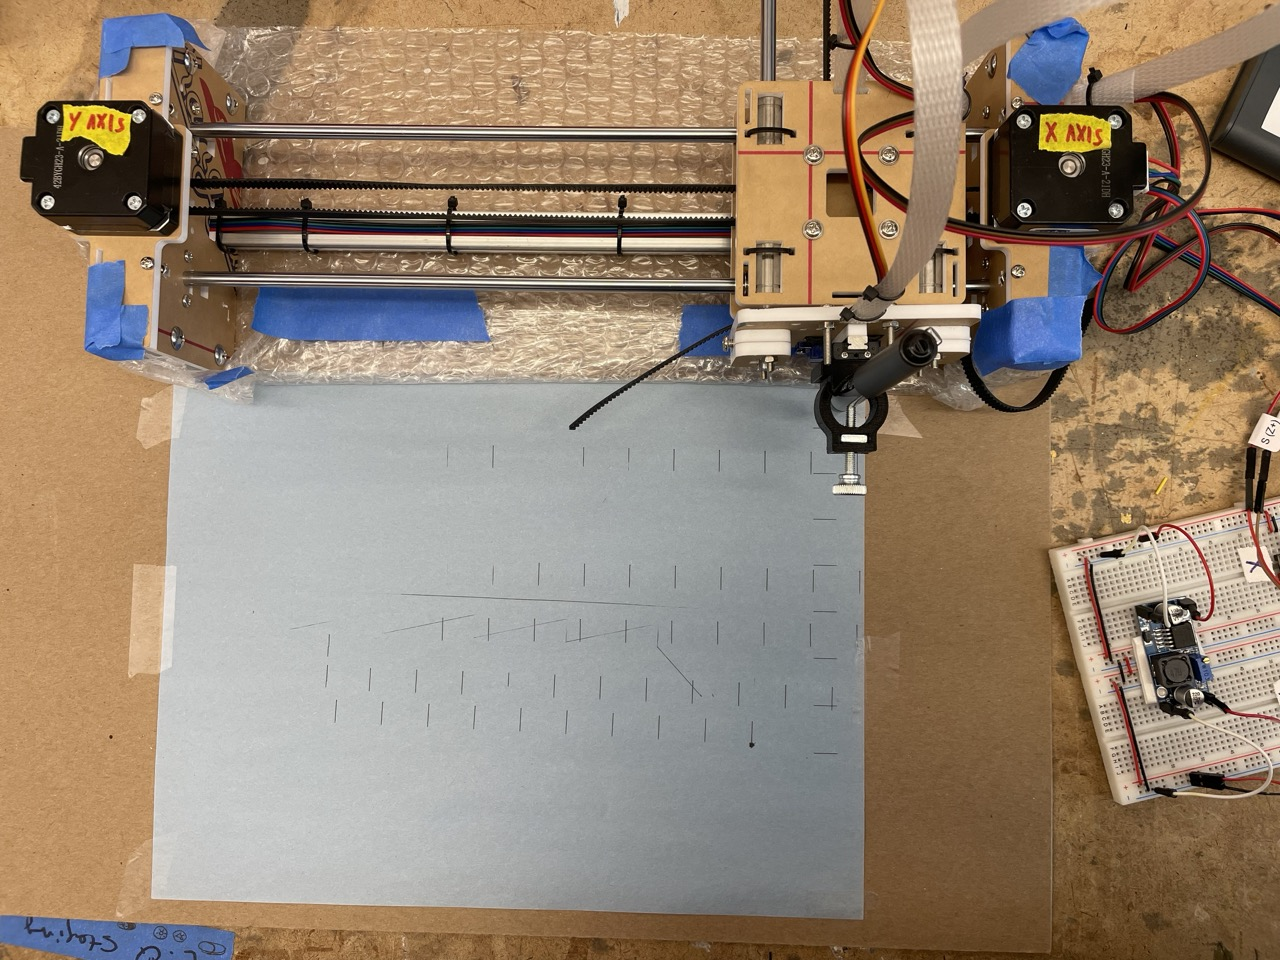

In [629]:
display(Image(filename='./documentation/IMG_8692.jpeg'))

# Setting up a DIY pen plotter
Originally I was going to build a pen plotter for my thesis project, however pretty early on in the process I realized it wasn't the right form for my concept. But I had already got most of the parts, and so when we got this pen-plotting assignment I figured, why not try it out now, it might be a fun spring break project. Little did I know... 

I got a breakout board that should've made life easier but the voltage regulator on it was damaged and so it essentially fried itself (the guy who makes them said he'd send a new one though). I decided to try and move forward without it so put everything I needed on a couple breadboards and handled the microcontroller myself.

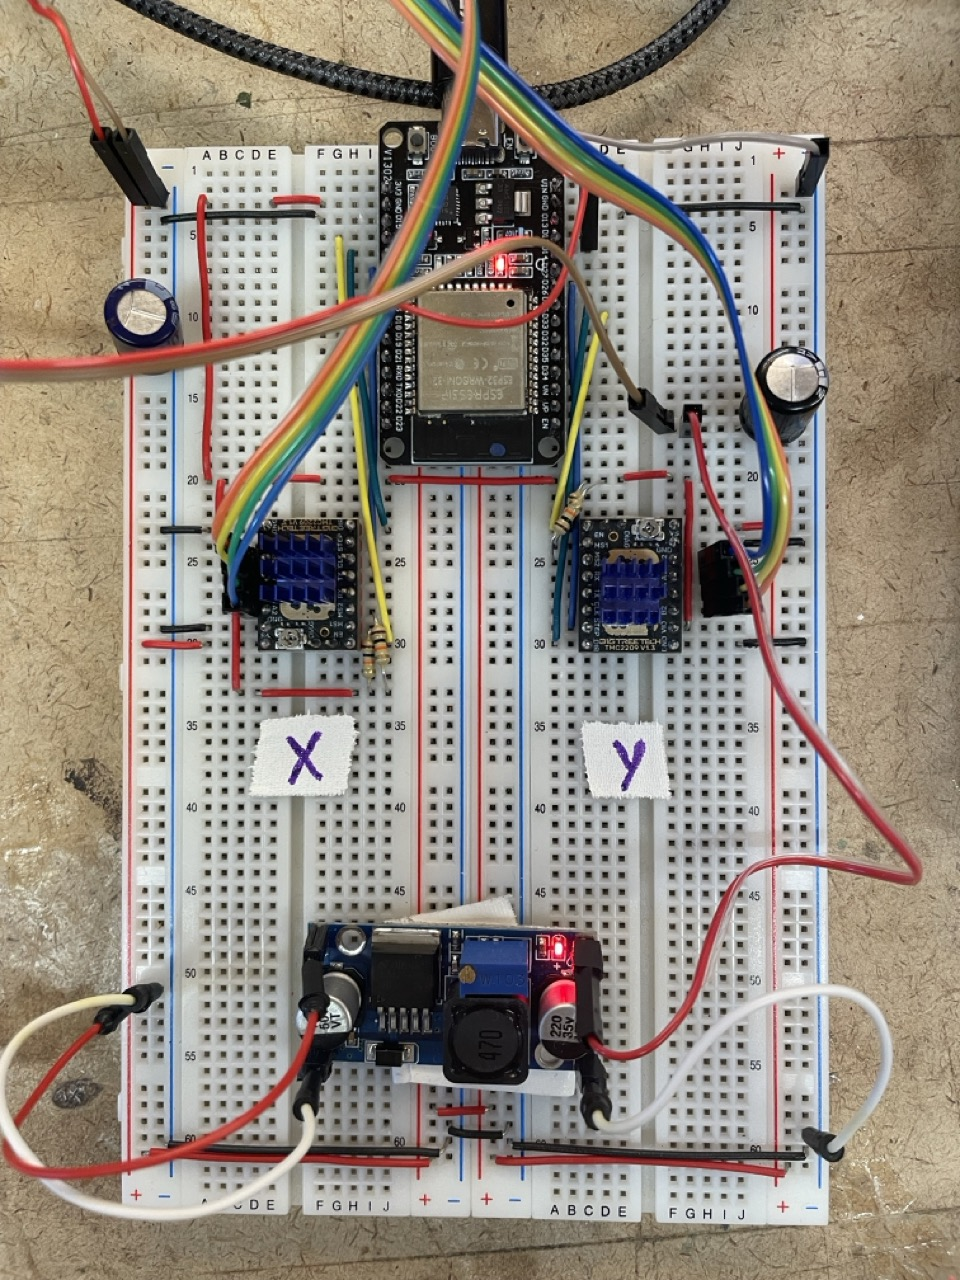

In [24]:
display(Image(filename='./documentation/IMG_8753.jpeg'))

To my understanding, most plotters work with G-code, a language for CNC machines, laser cutters, 3D printers, pen plotters or anything that needs to be operated physically on a number of axes. In order to interpret G-code instructions and translate that into actionable commands for the microcontroller (and motors), another library is used - GRBL.

I decided to use [FluidNC](http://wiki.fluidnc.com/en/home), a new version of the GRBL32 library that is optimized for the ESP32, a pretty decent, versatile and cheap microcontroller that has both WiFi and Bluetooth. 

My plotter uses a CoreXY design - a parallel motion system where two motors work together to move the pen in both X and Y directions. FluidNC handles a lot of the math for me, but in return it requires a precise configuration file to match the physical dimensions and characteristics of my specific build. I'm still working on that part, as my configuration is far from accurate but it works. Sort of.

Just a note on the sketch(es): I have used LLMs to assist me with testing and setting up - so many of the examples I plotted started that way. I thought I should keep the two separate - once I have my plotter working, I could work on actual interesting things to plot. That was a quick way to run tests such as the following:

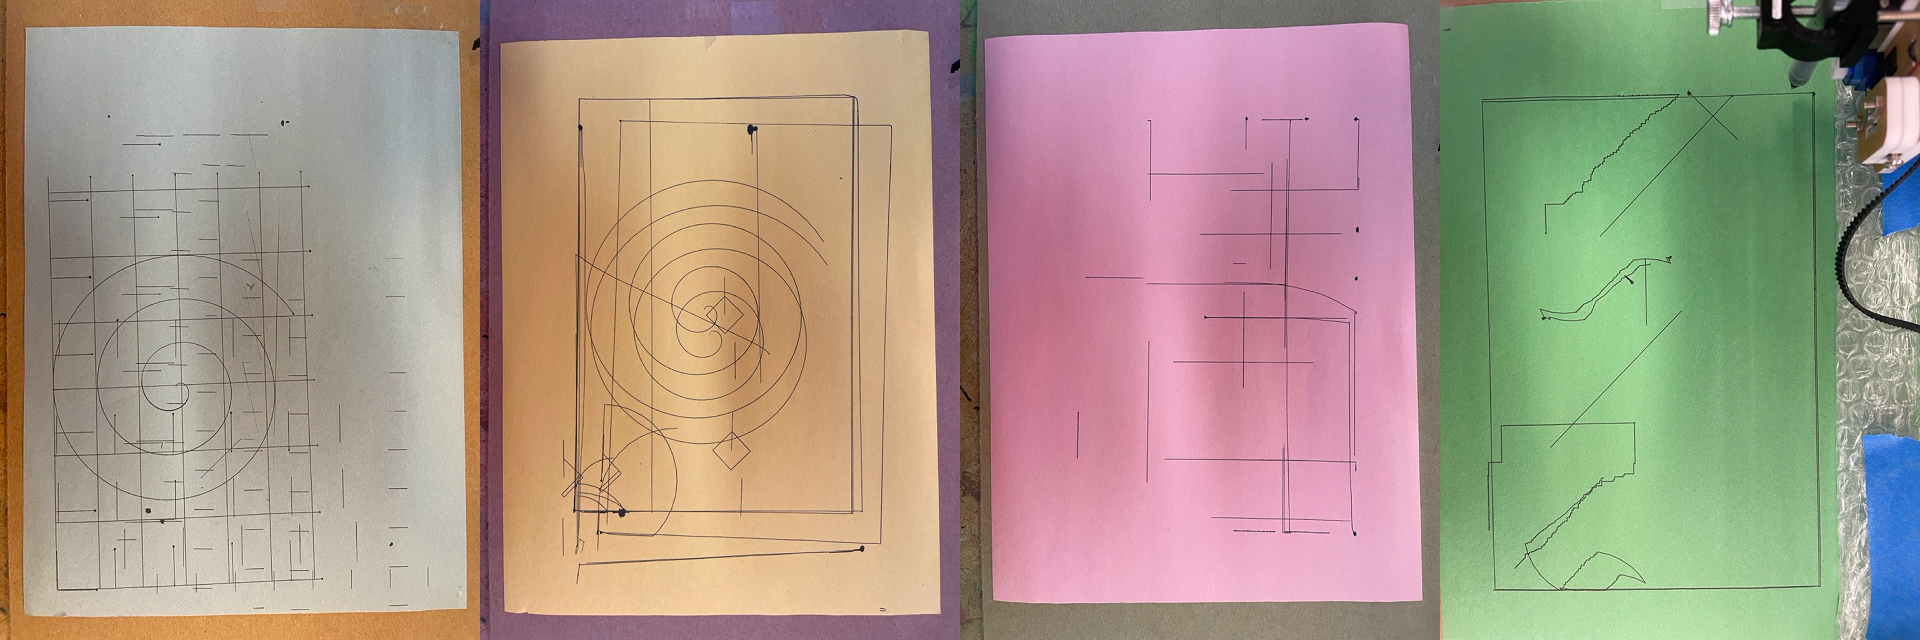

In [23]:
display(Image(filename='./documentation/00.jpg'))

In [21]:
import vsketch
import vpype
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import websocket
import subprocess
import random
import serial
import os
import math
from IPython.display import display, SVG

In [2]:
import serial.tools.list_ports

ports = list(serial.tools.list_ports.comports())
for p in ports:
    print(f"- {p}")

- /dev/cu.Bluetooth-Incoming-Port - n/a
- /dev/cu.usbserial-0001 - CP2102 USB to UART Bridge Controller


In [4]:
port  = "/dev/cu.usbserial-0001"

In [26]:
#some common variables
MAX_X = 110  #max X mm
MAX_Y = 75   #max Y mm
MARGIN = 10  #margins mm

TRAVEL_SPEED = 600   #travel speed mm/min
DRAWING_SPEED = 400  #drawing speed mm/min

In [31]:
def test_design(vsk):
    vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
    vsk.scale("mm")
    
    vsk.rect(MARGIN, MARGIN, MAX_X - 2*MARGIN, MAX_Y - 2*MARGIN)
    
    center_x = MAX_X / 2
    center_y = MAX_Y / 2
    vsk.line(center_x - 10, center_y, center_x + 10, center_y)
    vsk.line(center_x, center_y - 10, center_x, center_y + 10)
    
    vsk.circle(center_x, center_y, 5)
    
    return vsk

In [32]:
def display_design(vsk):
    vsk.display()
    return vsk

I struggled with trying to get vsketch sketches to the plotter. I haven't been able to solve this part yet, so I've requested the assistance of AI in writing some G-code. Could be interesting to do this in computational techniques as we've seen with HTML, but first I need to get this to work properly?

In [33]:
def generate_gcode(output):
    with open(output, "w") as f:
        f.write("; test G-code\n")
        f.write("; Working area: 0-110mm X, 0-75mm Y\n")
        f.write("G90 ; Absolute positioning\n")
        f.write("G21 ; Set units to mm\n")
        f.write("G1 Z0 F300 ; Pen up\n")
        
        # Draw a rectangle
        f.write(f"G0 X{MARGIN} Y{MARGIN} F{TRAVEL_SPEED} ; Move to start\n")
        f.write("G1 Z10 F300 ; Pen down\n")
        f.write(f"G1 X{MAX_X - MARGIN} Y{MARGIN} F{DRAWING_SPEED} ; Draw bottom edge\n")
        f.write(f"G1 X{MAX_X - MARGIN} Y{MAX_Y - MARGIN} F{DRAWING_SPEED} ; Draw right edge\n")
        f.write(f"G1 X{MARGIN} Y{MAX_Y - MARGIN} F{DRAWING_SPEED} ; Draw top edge\n")
        f.write(f"G1 X{MARGIN} Y{MARGIN} F{DRAWING_SPEED} ; Draw left edge\n")
        f.write("G1 Z0 F300 ; Pen up\n")
        
        # Draw a cross in the center
        center_x = MAX_X / 2
        center_y = MAX_Y / 2
        
        f.write(f"G0 X{center_x - 10} Y{center_y} F{TRAVEL_SPEED} ; Move to cross start\n")
        f.write("G1 Z10 F300 ; Pen down\n")
        f.write(f"G1 X{center_x + 10} Y{center_y} F{DRAWING_SPEED} ; Draw horizontal line\n")
        f.write("G1 Z0 F300 ; Pen up\n")
        
        f.write(f"G0 X{center_x} Y{center_y - 10} F{TRAVEL_SPEED} ; Move to cross start\n")
        f.write("G1 Z10 F300 ; Pen down\n")
        f.write(f"G1 X{center_x} Y{center_y + 10} F{DRAWING_SPEED} ; Draw vertical line\n")
        f.write("G1 Z0 F300 ; Pen up\n")
        
        # Return to a safe position
        f.write(f"G0 X{MARGIN} Y{MARGIN} F{TRAVEL_SPEED} ; Return to safe position\n")
    
    print(f"G-code file created: {output}")
    return output

In [34]:
def send_gcode_file(filename):
    try:
        #there were a lot of issues with conflicting serial and pyserial libraries. Importing here helps
        from serial import Serial
        
        ser = Serial(port, 115200, timeout=1)
        time.sleep(1)
        
        print("Starting...")
        ser.write("$X\n".encode()) #"$X" means "unlock" in Gcode language
        time.sleep(0.5)
        response = ser.readline().decode('utf-8', errors='ignore').strip()
        print(f"Response: {response}")
        
        print(f"Sending file: {filename}")
        with open(filename, 'r') as f:
            for i, line in enumerate(f):
                #skip comments and empty lines
                line = line.strip()
                if not line or line.startswith(';'):
                    continue
                
                print(f"Line {i+1}: {line}")
                ser.write(f"{line}\n".encode())
                time.sleep(0.1)
                
                response = ser.readline().decode('utf-8', errors='ignore').strip()
                print(f"Response: {response}")
                
                time.sleep(0.1)
        
        ser.close()
        print("File sent successfully!")
        return True
        
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        try:
            ser.close()
        except:
            pass
        return False

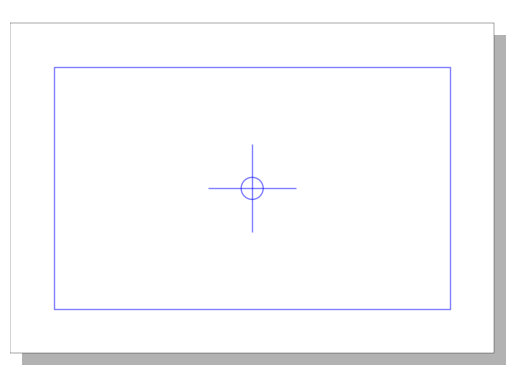

In [36]:
def test_test_design():
    vsk = vsketch.Vsketch()
    vsk = test_design(vsk)
    display_design(vsk)
    return vsk

tst_vsk = test_test_design()

In [39]:
def test_test_gcode():
    gcode_file = "simple_test.gcode"
    generate_gcode(gcode_file)
    
    send_to_plotter = input(f"Send {gcode_file} to plotter? (y/n): ")
    if send_to_plotter.lower() == 'y':
        send_gcode_file(gcode_file)
    else:
        print("Plotting cancelled.")

test_test_gcode()

G-code file created: simple_test.gcode


Send simple_test.gcode to plotter? (y/n):  n


Plotting cancelled.


And now for a simple attempt at asemic writing -
I thought I could have several "types" of characters, and generate words with random configuration (number and order of letters). Ideally the very generation of the characters would be more interesting but I wanted to set up an easily iterable system so started with the following:

In [59]:
def line_hook(x_start, y_base, width, height=None):
    if height is None:
        height = random.uniform(3, 8)
    
    hook_length = random.uniform(1, 4)
    
    points = []
    #start at the bottom
    points.append((x_start, y_base))
    #go up
    points.append((x_start, y_base - height))
    #add a hook to the right
    points.append((x_start + hook_length, y_base - height))
    
    return points

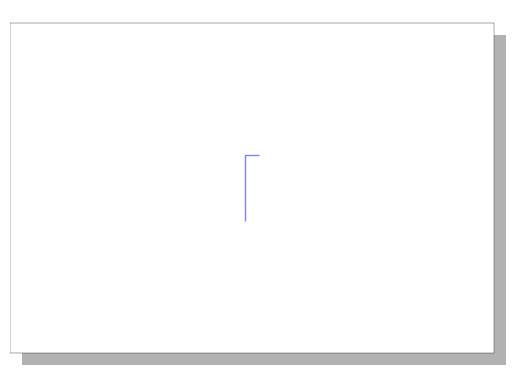

In [639]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
    
points = line_hook(center_x, center_y, 10, 15)
vsk.polygon(points)
    
vsk.display()

In [594]:
def curved_line(x_start, y_base, width, height):
    points = []
    for t in np.linspace(0, 1, 16):
        x = x_start + width * 0.8 * t
        y = y_base - height * math.sin(t * math.pi + random.uniform(0, 0.25)) 
        points.append((x, y))
    return points

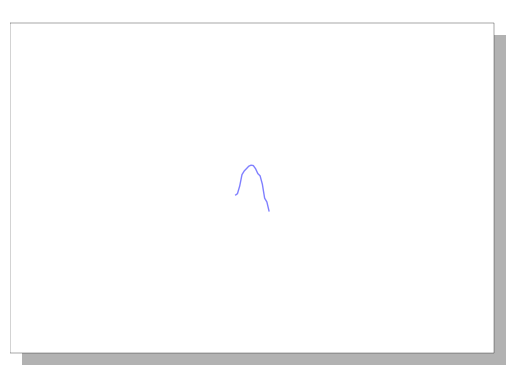

In [597]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
    
points = curved_line(center_x, center_y, random.uniform(2, 20), random.uniform(8,20))
vsk.polygon(points)
    
vsk.display()

In [41]:
def loop(x_start, y_base, width, height):
    points = []
    for t in np.linspace(0, 2*math.pi, 20):
        x = x_start + width * 0.4 * math.cos(t)
        y = y_base - height * 0.5 - height * 0.5 * math.sin(t)
        points.append((x, y))
    return points

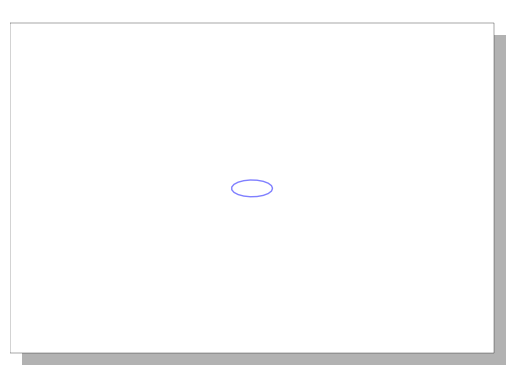

In [88]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
    
points = loop(center_x, center_y, random.uniform(3,20), random.uniform(3,12))
vsk.polygon(points)
    
vsk.display()

In [42]:
def zigzag(x_start, y_base, width, height):
    points = []
    points.append((x_start, y_base))
    points.append((x_start + width * 0.3, y_base - height * 0.5))
    points.append((x_start + width * 0.6, y_base - height))
    points.append((x_start + width * 0.9, y_base - height * 0.3))
    return points

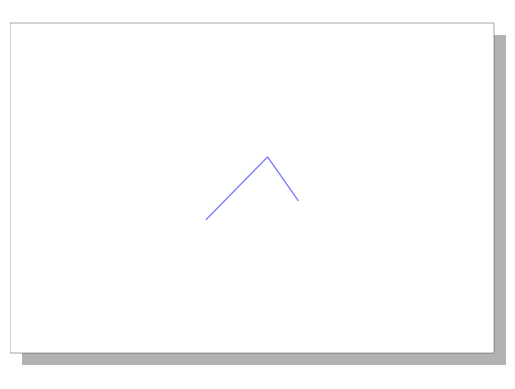

In [107]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
    
points = zigzag(center_x, center_y, random.uniform(6, 24), random.uniform(5,15))
vsk.polygon(points)
    
vsk.display()

In [114]:
def circle(x_start, y_base, width, radius=None):
    if radius is None:
        radius = random.uniform(0.5, 1.5)
    center_x = x_start + width * 0.5
    center_y = y_base - random.uniform(2, 5)
    
    points = []
    for t in np.linspace(0, 2*math.pi, 24):
        x = center_x + radius * math.cos(t)
        y = center_y + radius * math.sin(t)
        points.append((x, y))
    return points

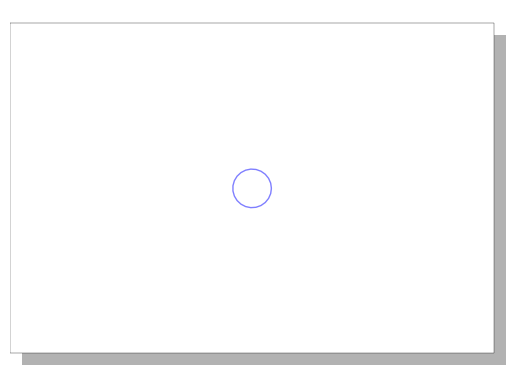

In [294]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
        
points = circle(center_x, center_y, random.uniform(1, 5), random.uniform(1, 6))
vsk.polygon(points)
    
vsk.display()

In [242]:
def scribble(x_start, y_base, width, height=None):
    if height is None:
        height = random.uniform(2, 15)
    
    points = []
    for t in np.linspace(0, 1, 5):
        x = x_start + width * 0.8 * t
        y = y_base - height * 0.5 - height * 0.5 * random.uniform(-1, 1)
        points.append((x, y))
    return points

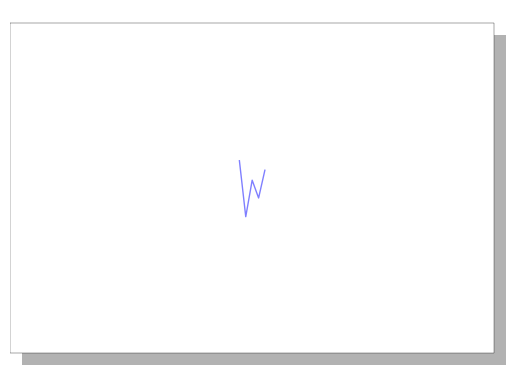

In [259]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
    
points = scribble(center_x, center_y, random.uniform(4, 16))
vsk.polygon(points)
    
vsk.display()

In [605]:
def writing(vsk):
    vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
    vsk.scale("mm")
    
    #random.seed(102)
    
    writing_area_x = MAX_X - 2*MARGIN
    writing_area_y = MAX_Y - 2*MARGIN
    
    num_lines = 5
    line_height = writing_area_y / (num_lines + 1)
    
    for line_num in range(num_lines):
        y_pos = MARGIN + (line_num + 1) * line_height
        
        x_pos = MARGIN
        num_words = random.randint(3, 8) 
        
        for word_num in range(num_words):
            word_width = random.uniform(10, 25)

            if x_pos + word_width > MAX_X - MARGIN:
                break
            
            num_chars = random.randint(2, 8)
            
            char_width = word_width / num_chars
            
            for i in range(num_chars):
                x_pos_char = x_pos + i * char_width
                
                char_type = random.randint(0, 5)
                
                if char_type == 0:
                    #line with hook
                    height = random.uniform(3, 8)
                    vsk.line(x_pos_char, y_pos, x_pos_char, y_pos - height)
                    vsk.line(x_pos_char, y_pos - height, x_pos_char + random.uniform(1, 3), y_pos - height)
                
                elif char_type == 1:
                    #curved line
                    height = random.uniform(3, 8)
                    points = curved_line(x_pos_char, y_pos, char_width, height)
                    vsk.polygon(points)
                
                elif char_type == 2:
                    #loop
                    height = random.uniform(3, 6)
                    points = loop(x_pos_char, y_pos, char_width, height)
                    vsk.polygon(points)
                
                elif char_type == 3:
                    #zigzag
                    height = random.uniform(3, 7)
                    points = zigzag(x_pos_char, y_pos, char_width, height)
                    vsk.polygon(points)
                
                elif char_type == 4:
                    #dot
                    radius = random.uniform(0.5, 1.5)
                    points = circle(x_pos_char, y_pos, char_width, radius)
                    vsk.polygon(points)
                
                else:
                    #scribble
                    height = random.uniform(2, 5)
                    points = scribble(x_pos_char, y_pos, char_width, height)
                    vsk.polygon(points)
            
            #move to the next word position
            x_pos += word_width + random.uniform(5, 8)
    
    return vsk

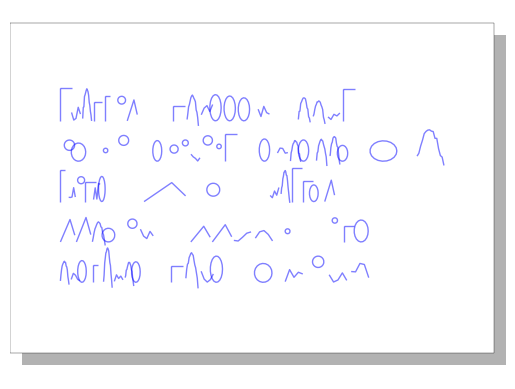

In [614]:
vsk = vsketch.Vsketch()
writing(vsk)
vsk.display()

After many failed attempts to generate Gcode from vsketch I caved and asked the AI to help with just generating Gcode in the same fashion. It is annoying though, because the way to actually get the same thing as in the vsketch version, it would have to have a set random seed, and copy it to the following function:

In [379]:
def writing_gcode(output_file):
    """Generate G-code directly from the writing logic"""
    random.seed(102)
    
    with open(output_file, "w") as f:
        # Write G-code header
        f.write("; G-code for writing\n")
        f.write("; Working area: 0-110mm X, 0-75mm Y\n")
        f.write("G90 ; Absolute positioning\n")
        f.write("G21 ; Set units to mm\n")
        f.write("G1 Z0 F300 ; Pen up\n")
        
        # Define the writing area
        writing_area_x = MAX_X - 2*MARGIN
        writing_area_y = MAX_Y - 2*MARGIN
        
        # Create several lines of "writing"
        num_lines = 5
        line_height = writing_area_y / (num_lines + 1)
        
        for line_num in range(num_lines):
            # Y position for this line
            y_pos = MARGIN + (line_num + 1) * line_height
            
            # Create "words" on this line
            x_pos = MARGIN
            num_words = random.randint(3, 8) 
            
            for word_num in range(num_words):
                word_width = random.uniform(10, 25)
                
                # Skip if we're at the edge
                if x_pos + word_width > MAX_X - MARGIN:
                    break
                
                num_chars = random.randint(2, 8)
                
                # Width per character
                char_width = word_width / num_chars
                
                # Create each "character"
                for i in range(num_chars):
                    x_pos_char = x_pos + i * char_width
                    
                    # Create a random scribble for this character
                    char_type = random.randint(0, 6)
                    
                    if char_type == 0:
                        # Line with hook
                        height = random.uniform(3, 8)
                        hook_length = random.uniform(1, 3)
                        
                        # Move to start
                        f.write(f"G0 X{x_pos_char:.3f} Y{y_pos:.3f} F{TRAVEL_SPEED}\n")
                        f.write("G1 Z10 F300 ; Pen down\n")
                        
                        # Draw vertical line
                        f.write(f"G1 X{x_pos_char:.3f} Y{y_pos - height:.3f} F{DRAWING_SPEED}\n")
                        
                        # Draw hook
                        f.write(f"G1 X{x_pos_char + hook_length:.3f} Y{y_pos - height:.3f} F{DRAWING_SPEED}\n")
                        
                        # Pen up
                        f.write("G1 Z0 F300 ; Pen up\n")
                    
                    elif char_type == 1:
                        # Curved line
                        height = random.uniform(3, 8)
                        points = curved_line(x_pos_char, y_pos, char_width, height)
                        
                        # Move to first point
                        f.write(f"G0 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{TRAVEL_SPEED}\n")
                        f.write("G1 Z10 F300 ; Pen down\n")
                        
                        # Draw the curve
                        for x, y in points[1:]:
                            f.write(f"G1 X{x:.3f} Y{y:.3f} F{DRAWING_SPEED}\n")
                        
                        # Pen up
                        f.write("G1 Z0 F300 ; Pen up\n")
                    
                    elif char_type == 2:
                        # Loop
                        height = random.uniform(3, 6)
                        points = loop(x_pos_char, y_pos, char_width, height)
                        
                        # Move to first point
                        f.write(f"G0 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{TRAVEL_SPEED}\n")
                        f.write("G1 Z10 F300 ; Pen down\n")
                        
                        # Draw the loop
                        for x, y in points[1:]:
                            f.write(f"G1 X{x:.3f} Y{y:.3f} F{DRAWING_SPEED}\n")
                        
                        # Close the loop
                        f.write(f"G1 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{DRAWING_SPEED}\n")
                        
                        # Pen up
                        f.write("G1 Z0 F300 ; Pen up\n")
                    
                    elif char_type == 3:
                        # Zigzag
                        height = random.uniform(3, 7)
                        points = zigzag(x_pos_char, y_pos, char_width, height)
                        
                        # Move to first point
                        f.write(f"G0 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{TRAVEL_SPEED}\n")
                        f.write("G1 Z10 F300 ; Pen down\n")
                        
                        # Draw the zigzag
                        for x, y in points[1:]:
                            f.write(f"G1 X{x:.3f} Y{y:.3f} F{DRAWING_SPEED}\n")
                        
                        # Pen up
                        f.write("G1 Z0 F300 ; Pen up\n")
                    
                    elif char_type == 4:
                        # Circle
                        radius = random.uniform(0.5, 1.5)
                        points = circle(x_pos_char, y_pos, char_width, radius)
                        
                        # Move to first point
                        f.write(f"G0 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{TRAVEL_SPEED}\n")
                        f.write("G1 Z10 F300 ; Pen down\n")
                        
                        # Draw the circle
                        for x, y in points[1:]:
                            f.write(f"G1 X{x:.3f} Y{y:.3f} F{DRAWING_SPEED}\n")
                        
                        # Close the circle
                        f.write(f"G1 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{DRAWING_SPEED}\n")
                        
                        # Pen up
                        f.write("G1 Z0 F300 ; Pen up\n")
                    
                    else:
                        # Scribble
                        height = random.uniform(2, 5)
                        points = scribble(x_pos_char, y_pos, char_width, height)
                        
                        # Move to first point
                        f.write(f"G0 X{points[0][0]:.3f} Y{points[0][1]:.3f} F{TRAVEL_SPEED}\n")
                        f.write("G1 Z10 F300 ; Pen down\n")
                        
                        # Draw the scribble
                        for x, y in points[1:]:
                            f.write(f"G1 X{x:.3f} Y{y:.3f} F{DRAWING_SPEED}\n")
                        
                        # Pen up
                        f.write("G1 Z0 F300 ; Pen up\n")
                
                # Move to the next word position
                x_pos += word_width + random.uniform(5, 8)  # Space between words
        
        # Return to a safe position
        f.write(f"G0 X{MARGIN} Y{MARGIN} F{TRAVEL_SPEED} ; Return to safe position\n")
    
    print(f"G-code file created: {output_file}")
    return output_file

In [380]:
gcode = "writing.gcode"
writing_to_gcode(gcode)

send_to_plotter = input(f"Send {gcode_file} to plotter? (y/n): ")
if send_to_plotter.lower() == 'y':
    send_gcode_file(gcode_file)
else:
    print("Plotting cancelled.")

G-code file created: writing.gcode


Send writing.gcode to plotter? (y/n):  n


Plotting cancelled.


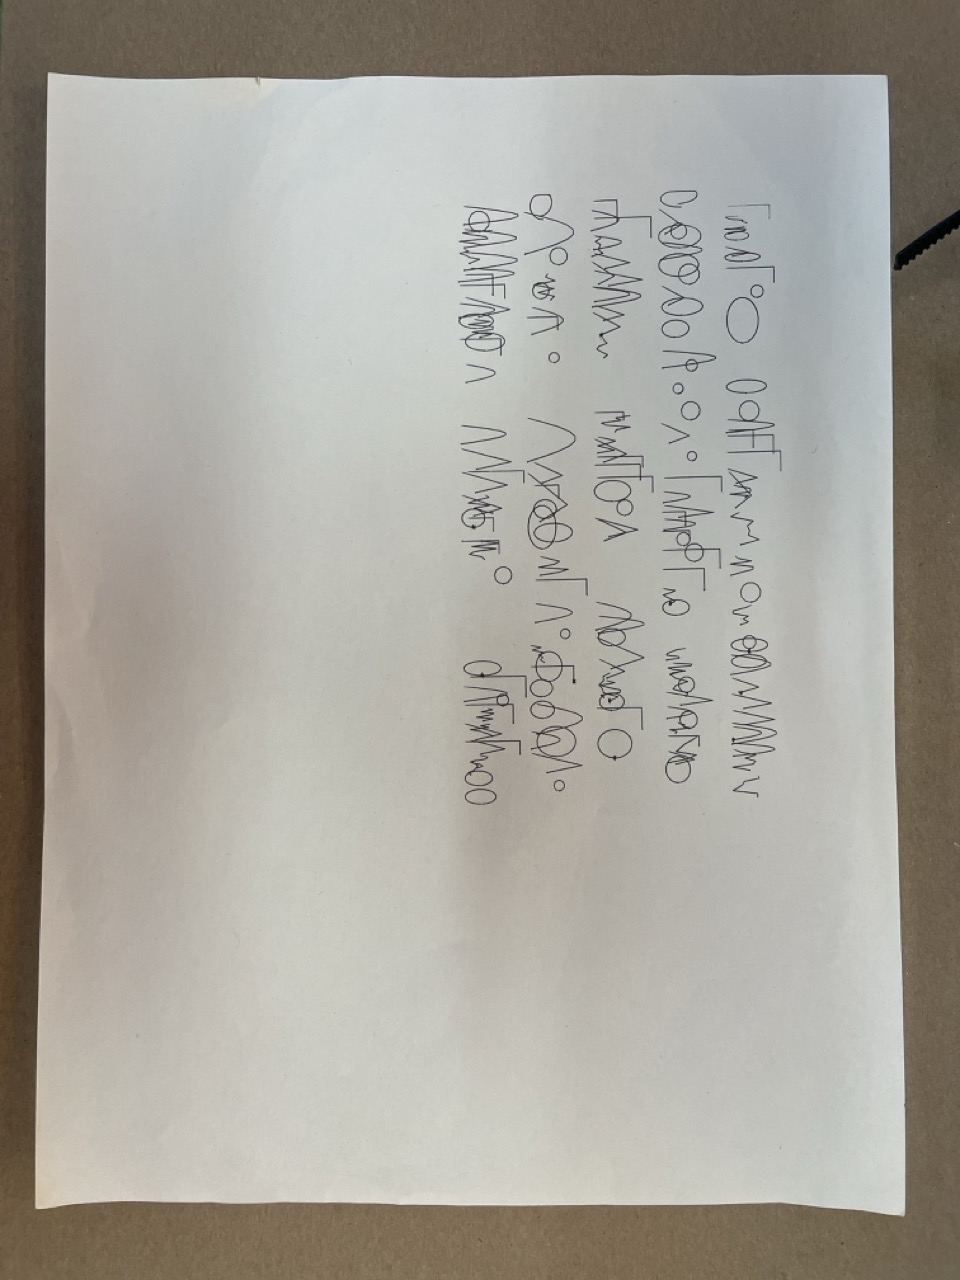

In [630]:
display(Image(filename='./documentation/IMG_8754.jpeg'))

And now I just want to quickly try just the scribbles

In [509]:
def scribble_01(x_start, y_base, width, height=None):
    if height is None:
        height = random.uniform(2, 25)
    
    points = []
    for t in np.linspace(0, 1, 7):
        x = x_start + width * 0.99 * t
        y = y_base - height * 0.5 - height * 0.5 * random.uniform(-1, 1)
        points.append((x, y))
    return points

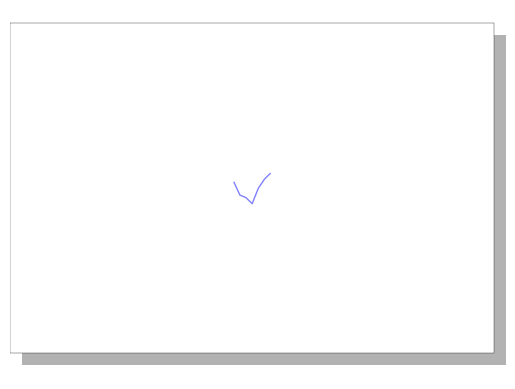

In [510]:
vsk = vsketch.Vsketch()
vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
vsk.scale("mm")
    
center_x = MAX_X / 2
center_y = MAX_Y / 2
    
points = scribble_01(center_x, center_y, random.uniform(4, 10))
vsk.polygon(points)
    
vsk.display()

In [618]:
def writing_01(vsk):
    vsk.size(f"{MAX_X}mm", f"{MAX_Y}mm")
    vsk.scale("mm")
    
    #random.seed(102)
    
    writing_area_x = MAX_X - 2*MARGIN
    writing_area_y = MAX_Y - 2*MARGIN
    
    num_lines = 5
    line_height = writing_area_y / (num_lines)
    
    for line_num in range(num_lines):
        y_pos = MARGIN + (line_num + 1) * line_height
        
        x_pos = MARGIN
        num_words = random.randint(2, 8) 
        
        for word_num in range(num_words):
            word_width = random.uniform(10, 25)

            if x_pos + word_width > MAX_X - MARGIN:
                break
            
            num_chars = random.randint(2, 8)
            
            char_width = word_width / num_chars
            
            for i in range(num_chars):
                x_pos_char = x_pos + i * char_width
                
                char_type = random.randint(0, 1)
                
                if char_type == 0:
                    #curved line
                    height = random.uniform(3, 8)
                    points = curved_line(x_pos_char, y_pos, char_width, height)
                    vsk.polygon(points)
                
                elif char_type == 1:
                    #scribble
                    scribble_height = random.uniform(2, 9)
                    points = scribble_01(x_pos_char, y_pos, char_width, scribble_height)
                    vsk.polygon(points)
                    
            
            x_pos += word_width + random.uniform(5, 8)
    
    return vsk

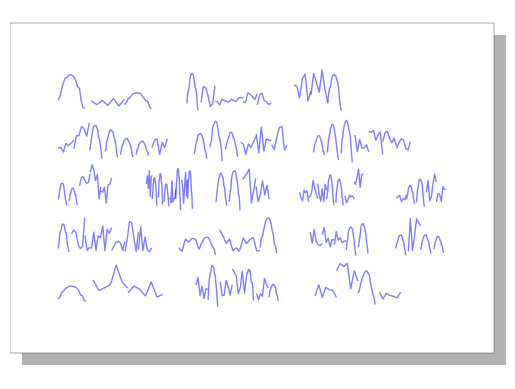

In [628]:
vsk = vsketch.Vsketch()
writing_01(vsk)
vsk.display()